First we import the library, forcing reload from local version (not pip install). 

In [1]:
import os
import sys
import importlib
import matplotlib.pyplot as plt


# Get the absolute path to the directory containing the local module
stlrom_path = os.path.abspath('../build')
print(stlrom_path)

# Insert the local module path at the beginning of sys.path
sys.path.insert(0, stlrom_path)

import stlrom

# Reload the module to ensure it is loaded from the new path
importlib.reload(stlrom)

import stlrom as sr
import numpy as np

print(sr.Signal.get_interpol())


/home/dayekhh/Documents/git-repos/stlrom2/build
LINEAR


# Signals


## Function


In [2]:
import matplotlib.pyplot as plt

# Plotting
def plot_signal(signal,label=None, fig=None):
    samples_list = signal.get_samples_list()

    if fig is None:
        fig = plt.figure(figsize=(15, 5)).gca()

    if label is None:
        label = f'Signal {len(fig.get_lines()) + 1}'

    fig.set_xlabel('Time')
    fig.set_ylabel('Value')
    fig.set_title('Signal Plot')
    fig.grid(True)
        
    def plot_sample(s, dt, color=None):
        if color is None:
            l, = fig.plot(s.time, s.value, marker='o')
            color = l.get_color()
            l = fig.plot([s.time, s.time+dt], [s.value, s.value_at(s.time+dt)], color=color, linestyle='-')
        else:
            l = fig.plot(s.time, s.value, marker='o', color=color)
            l = fig.plot([s.time, s.time+dt], [s.value, s.value_at(s.time+dt)], color=color, linestyle='-')
        return color,l
    
    if len(samples_list) > 1:
        s = samples_list[0]
        sn = samples_list[1]
        dt = sn.time-s.time
            
        col,l = plot_sample(s, dt)
        
        
        for i in range(1, len(samples_list)-1):
            s = samples_list[i]
            sn = samples_list[i+1]
            dt = sn.time-s.time
            plot_sample(s,dt,color=col)
    else:
        sn = samples_list[0]
        col = None
    
    col, l = plot_sample(sn, signal.end_time-sn.time, col)
    l[0].set_label(label)
    #fig.plot(sn.time, sn.value, marker='o', color=col)
    fig.legend()
    fig.figure.canvas.draw()

    return fig

# Printing
def print_signal(signal):
    for s in signal.get_samples_list():
        s.print_sample()
    print('begin_time ', signal.begin_time)
    print('end_time    ',signal.end_time)



## Test signals

### Basic test signals

In [3]:
# One sample
sig0 = sr.Signal()
sig0.append_sample(0, -1)
sig0.append_sample(1., 1)

sig1 = sr.Signal()
sig1.append_sample(.3, 2)
sig1.append_sample(.6, 1.5)
sig1.append_sample(1.3, -3)



### Longer signals

<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

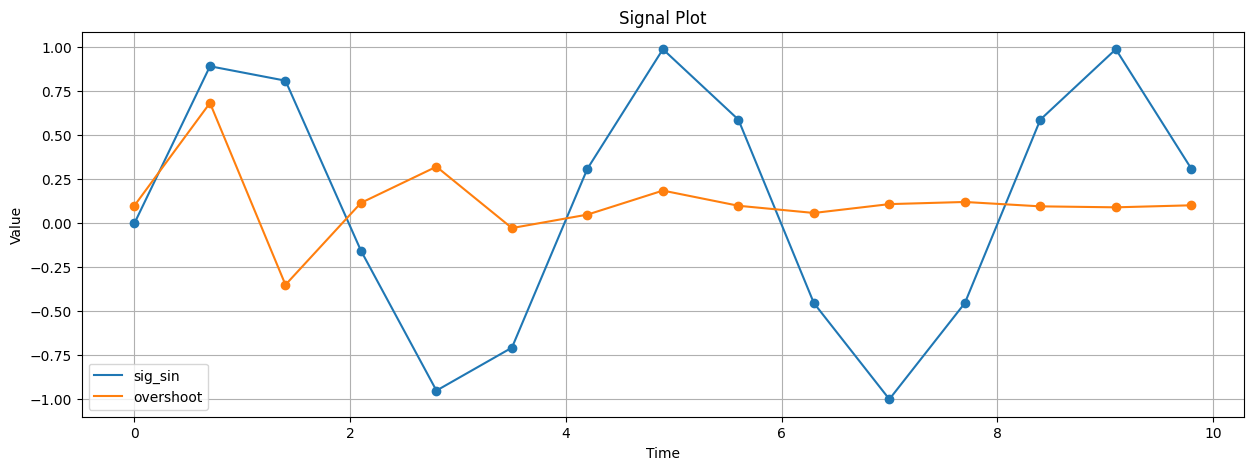

In [ ]:
times = np.arange(0, 10.1, .35)
sin_val = np.sin(times*np.pi/2)
overshoot_val = np.sin(times*np.pi*np.exp(-times/50))*np.exp(-times/2)+.1
sig_sin = sr.Signal()
sig_overshoot = sr.Signal()

for i in range(0,len(times)):
    sig_sin.append_sample(times[i],sin_val[i])
    sig_overshoot.append_sample(times[i],overshoot_val[i])

fig= plot_signal(sig_sin, 'sig_sin')
plot_signal(sig_overshoot, 'overshoot', fig)


# Testing monitors


In [5]:
stl_parser = stlrom.STLDriver()
stl_parser.parse_string("""signal x, y       # declaring signals named 'x' and 'y'
param p=0.2, tau=5  # declaring parameters named 'p' and 'q'
# Let's add some formulas
mu_x := x[t] > p
mu_eq := x[t] == p 
mu_neq := not mu_eq
phi_x := ev_[0, tau] ( mu_x )
mu_y := y[t] < p 
mu := mu_x and mu_y 
phi_y := y[t]>p => ev_[0, tau] (y[t]<p)
""")


True

In [6]:
# Helper, to add data to a monitor
def add_signals(mon,times, sig_x, sig_y):
    for i in range(0, len(times)):
        mon.add_sample([times[i],sig_x[i],sig_y[i]])
    return mon


Monitoring phi_x

In [7]:
phi_x = stl_parser.get_monitor("phi_x")
phi_x_ltr = stl_parser.get_monitor("phi_x")

phi_x = add_signals(phi_x, times, sin_val, overshoot_val)
phi_x_ltr = add_signals(phi_x_ltr, times, sin_val, overshoot_val)



In [8]:
phi_x.data

[[0.0, 0.0, 0.1],
 [0.7, 0.8910065241883678, 0.6824997836756516],
 [1.4, 0.8090169943749475, -0.3502123654970869],
 [2.0999999999999996, -0.1564344650402303, 0.11497592234974044],
 [2.8, -0.9510565162951535, 0.32058867468459906],
 [3.5, -0.7071067811865477, -0.027931134355753923],
 [4.199999999999999, 0.30901699437494634, 0.04842213034672543],
 [4.8999999999999995, 0.9876883405951375, 0.18489334725075307],
 [5.6, 0.5877852522924734, 0.09873008562120615],
 [6.3, -0.45399049973954564, 0.05776698331412903],
 [7.0, -1.0, 0.1080147180842651],
 [7.699999999999999, -0.453990499739548, 0.12021758710952865],
 [8.399999999999999, 0.5877852522924712, 0.09532257438708469],
 [9.1, 0.987688340595138, 0.08981411907197573],
 [9.799999999999999, 0.30901699437494967, 0.10129687168989848]]

In [9]:
phi_x_ltr.set_semantics("LEFT_TIME")

print(phi_x.get_semantics())
print(phi_x_ltr.get_semantics())

SPACE
LEFT_TIME


In [10]:
phi_x.set_eval_time(0,5)
phi_x.eval_rob()

0.7876883405951376

In [11]:
print_signal(phi_x.get_signal())

begin_time Time 0.00000 Value 0.78769 Derivative 0.00000
Time 4.10000 Value 0.78769 Derivative 0.57129
Time 4.10000 Value 0.78769 Derivative 0.00000
 0.0
end_time     5.0


## Some plots

In [12]:
mu_x = stl_parser.get_monitor("mu_x")
print(mu_x.data)
mu_x = add_signals(mu_x, times, sin_val, overshoot_val)
print(mu_x.data)

mu_eq = stl_parser.get_monitor("mu_eq")
mu_eq = add_signals(mu_eq, times, sin_val, overshoot_val)

[]
[[0.0, 0.0, 0.1], [0.7, 0.8910065241883678, 0.6824997836756516], [1.4, 0.8090169943749475, -0.3502123654970869], [2.0999999999999996, -0.1564344650402303, 0.11497592234974044], [2.8, -0.9510565162951535, 0.32058867468459906], [3.5, -0.7071067811865477, -0.027931134355753923], [4.199999999999999, 0.30901699437494634, 0.04842213034672543], [4.8999999999999995, 0.9876883405951375, 0.18489334725075307], [5.6, 0.5877852522924734, 0.09873008562120615], [6.3, -0.45399049973954564, 0.05776698331412903], [7.0, -1.0, 0.1080147180842651], [7.699999999999999, -0.453990499739548, 0.12021758710952865], [8.399999999999999, 0.5877852522924712, 0.09532257438708469], [9.1, 0.987688340595138, 0.08981411907197573], [9.799999999999999, 0.30901699437494967, 0.10129687168989848]]


interpol:LINEAR
interpol:LINEAR
0.00000 0.70000
0.00079
0.00000 0.70000
0.00079
0.00000 0.70000
0.00079
interpol:LINEAR
0.00000 0.70000
0.00079
0.00000 0.70000
0.00079
0.00000 0.70000
0.00079
begin_time  0.0
end_time     9.799999999999999
Time 0.00000 Value 3.00000 Derivative 0.00000
Time 0.00079 Value -0.00100 Derivative -1.27287
Time 0.70000 Value -0.89101 Derivative 0.11713
Time 1.40000 Value -0.80902 Derivative 1.37922
Time 1.98585 Value 3.00000 Derivative 0.00000
Time 1.98730 Value -0.00100 Derivative -1.37922
Time 2.10000 Value -0.15643 Derivative -1.13517
Time 2.80000 Value -0.95106 Derivative 0.34850
Time 3.50000 Value -0.70711 Derivative 1.45161
Time 3.98643 Value 3.00000 Derivative 0.00000
Time 3.98781 Value -0.00100 Derivative -1.45161
Time 4.20000 Value -0.30902 Derivative -0.96953
Time 4.90000 Value -0.98769 Derivative 0.57129
Time 5.60000 Value -0.58779 Derivative 1.48825
Time 5.99428 Value 3.00000 Derivative 0.00000
Time 5.99562 Value -0.00100 Derivative -1.48825
Time 6.

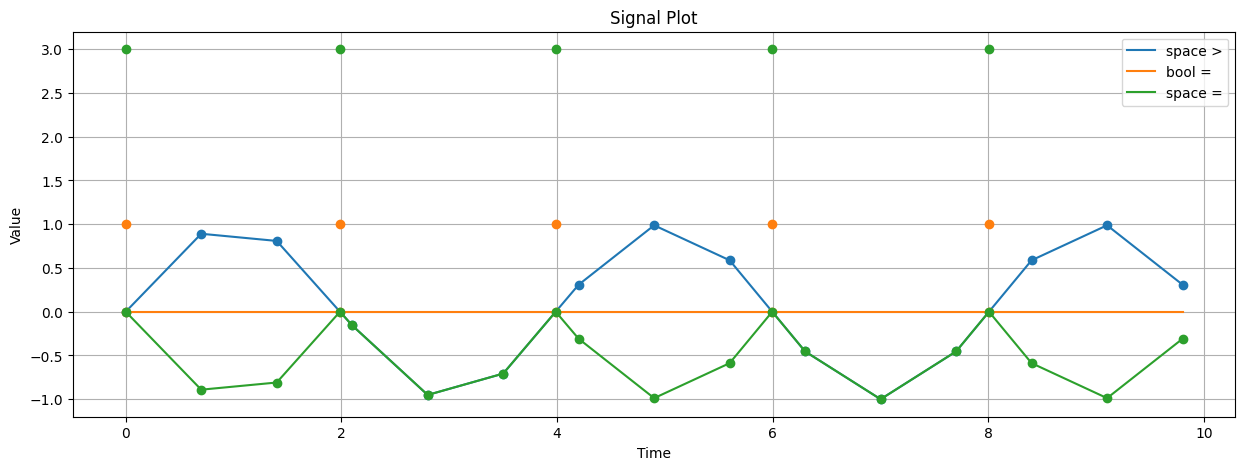

In [ ]:
stlrom.Signal.set_BigM(3)
stlrom.Signal.set_Eps(0.001)

mu_x.set_eval_time(0, 10) 
mu_eq.set_eval_time(0, 10)

mu_x.set_param("p", 0)
mu_eq.set_param("p", 0)

interp = "LINEAR"

mu_x.set_semantics("SPACE")
mu_x.set_interpol(interp)
mu_x.eval_rob()
z_space = mu_x.get_signal()
fig = z_space.plot(label="space >")



mu_eq.set_semantics("BOOLEAN")
mu_eq.set_interpol(interp)
mu_eq.eval_rob()
z_bool = mu_eq.get_signal()
fig = z_bool.plot(label="bool =", fig=fig)


mu_eq.set_semantics("SPACE")
mu_eq.set_interpol(interp)
mu_eq.eval_rob()
z_space_eq = mu_eq.get_signal()
fig = z_space_eq.plot(label="space =", fig=fig)



# mu_x.set_semantics("LEFT_TIME")
# mu_x.eval_rob()
# z_space = mu_x.get_signal()
# plot_signal(z_space, label="ltr", fig=fig)

# mu_x.set_semantics("RIGHT_TIME")
# mu_x.eval_rob()
# z_space = mu_x.get_signal()
# plot_signal(z_space, label="rtr", fig=fig)

# mu_x.set_semantics("BOOLEAN")
# mu_x.eval_rob()
# z_space = mu_x.get_signal()
# plot_signal(z_space, label="boolean", fig=fig)

<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

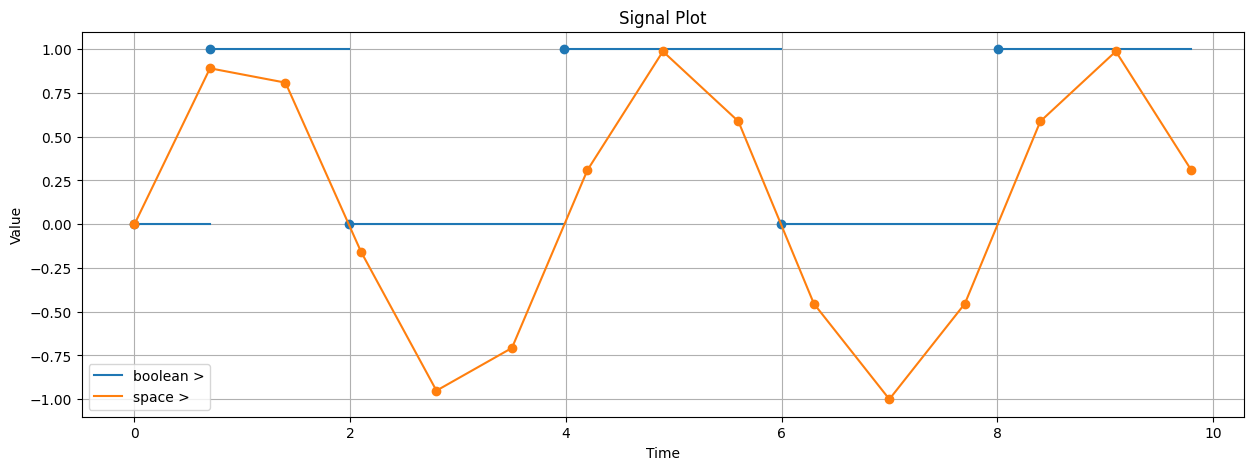

In [14]:
mu_x.set_semantics("BOOLEAN")
mu_x.eval_rob()
z_boolean_x = mu_x.get_signal()
fig2 = z_boolean_x.plot(label="boolean >")

mu_x.set_semantics("SPACE")
mu_x.eval_rob()
z_boolean_x = mu_x.get_signal()
z_boolean_x.plot(label="space >", fig=fig2)

In [15]:
mu_x.set_eval_time(0, 10) 
ev_x.set_eval_time(0,6)
mu_x.set_param('p', .3)
ev_x.set_param('p', .3)

mu_x.eval_robustness()
rho_mu_x = mu_x.get_signal()
ev_x.eval_robustness()
rho_ev_x = ev_x.get_signal()


fig = plot_signal(rho_mu_x, 'mu_x')
plot_signal(rho_ev_x, 'rho(ev_x)', fig)


NameError: name 'ev_x' is not defined

In [ ]:

print_signal(rho_ev_x)

In [ ]:
ev_x